# Pipeline MLOps
- Autor: Jefferson Silva (https://github.com/isjustjefferson)
- Base de dados: Telco Customer Churn
- Tipo de tarefa: Classificação Binária

## Escolha e Importação da Base de Dados

- Descrição objetiva: A base de dados Telco Customer Churn contém informações sobre clientes de uma empresa de telecomunicações, incluindo serviços assinados, informações de conta e dados demográficos, com o intuito de prever quais clientes deixarão a empresa. A base possui 7043 linhas e 21 colunas, onde cada linha representa um cliente (customer) e cada coluna representa informações sobre esses clientes (customer's attributes).
- URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data
- Paradigma de Aprendizagem: Aprendizagem Supervisionada
    - O modelo é treinado utilizando dados históricos onde as características do cliente (features) e o resultado final (se ele cancelou ou não o serviço — rótulo/alvo) são conhecidos. O algoritmo aprende os padrões que levam ao cancelamento para classificar novos casos.
- Tarefa de IA: Classificação Binária
    - Esta é uma tarefa de classificação onde o objetivo é prever uma entre duas categorias possíveis: "Yes" (Churn/Rompimento) ou "No" (Retenção). O modelo analisa variáveis independentes para estimar a probabilidade de um cliente pertencer a uma dessas classes discretas.

In [59]:
# importação de bibliotecas
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# importação da base de dados (dataset)
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Estatísticas Descritivas

In [ ]:
# informações iniciais da base

print(f"Total de linhas e colunas: {df.shape}\n") # 7043, 21

print(f"Total de valores nulos para cada coluna:")
print(df.isnull().sum()) # sem dados faltantes

print(f"\nTotal de linhas duplicadas: {df.duplicated().sum()}") # sem linhas duplicadas

print("\nTipos de dados presentes em cada coluna: ")
print(df.dtypes) # 18 colunas possuem dados do tipo object que, na maioria dos casos, são strings

print(f"\nDescrição: {df.describe()}") # somente dados numéricos 

print("\nCinco primeiras linhas da base de dados: ")
df.head()

Total de linhas e colunas: (7043, 21)

Total de valores nulos para cada coluna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total de linhas duplicadas: 0

Tipos de dados presentes em cada coluna: 
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
Streami

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- A base possui 7043 linhas, onde cada uma representa um cliente, e 21 colunas, onde cada representa informações do cliente, dividas em:
    - `customerID` (trad.: IDCliente): Um id único para cliente no formato 0000-XXXXX (`object`),
    - `gender` (trad.: gênero): gênero do cliente, somente "male" (homem) e "female" (mulher) (`object`),
    - `SeniorCitizen` (trad.: CidadaoSenior): inteiro que informa se o cliente é um idoso ou não (1 é idoso, 0 não) (`int`),
    - `Partner` (trad.: Parceiro): string (preenchida somente com "Yes" ou "No") que informa se o cliente possui parceiro (`object`),
    - `Dependents` (trad.: Dependentes): string (preenchida somente com "Yes" ou "No") que informa se o cliente possui dependentes (`object`),
    - `tenure` (trad.: vigência): inteiro que informa quantos meses o cliente esteve com a companhia (`int`),
    - `PhoneService` (trad.: ServicoTelefone): string (preenchida somente com "Yes" ou "No") que informa se o cliente possui serviço de telefone (`object`),
    - `MultipleLine` (trad.: MultiplasLinhas): string (preenchida com "Yes" ou "No") que informa se o cliente possui múltiplas linhas telefônicas. Caso não possua serviço de telefone, é preenchido com "No phone service" (`object`),
    - `InternetService` (trad.: ServicoInternet): string (preenchida com "DSL", "Fiber optic" ou "No") que informa se o cliente possui serviço de internet (`object`),
    - `OnlineSecurity` (trad.: SegurancaOnline):  string (preenchida com "Yes" ou "No") que informa se o cliente possui segurança online. Caso não possua serviço de internet, é preenchido com "No internet service" (`object`),
    - `OnlineBackup` (trad.: BackupOnline): string (preenchida com "Yes" ou "No") que informa se o cliente possui backup online. Caso não possua serviço de internet, é preenchido com "No internet service" (`object`),
    - `DeviceProtection` (trad.: ProtecaoDispositivo): string (preenchida com "Yes" ou "No") que informa se o cliente possui proteção aos dispositivos. Caso não possua serviço de internet, é preenchido com "No internet service" (`object`),
    - `TechSupport` (trad.: SuporteTecnico): string (preenchida com "Yes" ou "No") que informa se o cliente possui suporte técnico. Caso não possua serviço de internet, é preenchido com "No internet service" (`object`),
    - `StreamingTV` (trad.: TVAssinatura): string (preenchida com "Yes" ou "No") que informa se o cliente possui TV por assinatura. Caso não possua serviço de internet, é preenchido com "No internet service" (`object`),
    - `StreamingMovies` (trad.: FilmesAssinatura): string (preenchida com "Yes" ou "No") que informa se o cliente possui filmes por assinatura. Caso não possua serviço de internet, é preenchido com "No internet service" (`object`),
    - `Contract` (trad.: Contrato): string (preenchida com "Month-to-month", "One year" ou "Two year") que informa o prazo do contrato do cliente (`object`),
    - `PaperlessBilling` (trad.: ContaSemPapel): string (preenchida com "Yes" ou "No") que informa se o cliente possui conta sem papel (`object`),
    - `PaymentMethod` (trad.: MetodoPagamento): string (preenchida com "Electronic check", "Mailed check", "Bank transfer (automatic) ou "Credit card (automatic)") que informa o método de pagamento do cliente (`object`),
    - `MonthlyCharges`: O valor cobrado ao cliente mensalmente (`float`),
    - `Total Charges`: float que informa valor total cobrado ao cliente durante vigência do contrato (`float`),
    - `Churn`: string (preenchia com "Yes" ou "No") que informa se o cliente rompeu o contrato (`object`).
- A base, nativamente, é tratável para um problema de classificação, pois é suscetível a problemas de possibilidade e proximidade entre os dados, ou seja, entender como, quando e em quais condições os clientes de certas empresas tiveram uma determinada decisão sobre a vigência do contrato.
- Não há dados faltantes, nem linhas duplicadas, o que, a princípio, não exige nenhum tratamento dos dados da base.
- Por meio do comando `.describe()` algumas informações importantes sobre os dados numéricos puderam ser observadas: 
    - `SeniorCitizen`: Cerca de 0.16 (16%) dos clientes são idosos.
    - `tenure`: 
        - Minímo 0 e máximo 72 meses, com média em 32 e mediana em 29 (leve assimetria à direita, esperado nesse tipo de problema).
        - O std em 24 revela que há uma distribuição espalhada, indicando que há clientes recente e antigos na base. 
        - Clientes com `tenure = 0` merecem atenção, podendo ser registros do mês de entrada, indicando possíveis dados incompletos.
    - `MonthlyChanges`:
        - Varia entre 18 a 119, com média em 64 e media em 70 (leve assimetria à esquerda).
        - Esta leve assimetria à esquerda sugere que há um grupo de clientes com plano muito baratos, puxando a média para baixo.
        - Há sentido em cruzar com a taxa de churn, pois planos mais caros tendem a cancelar mais. 
    - O fato de `TotalCharges` não aparecer indica que ele está no formato de dado errado, isso será corrigido no pré-processamento.

## Distribuição do alvo (Churn)

Distribuição de churns (rompimento do contrato): 
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Distribuição de churns em porcentagem: 
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

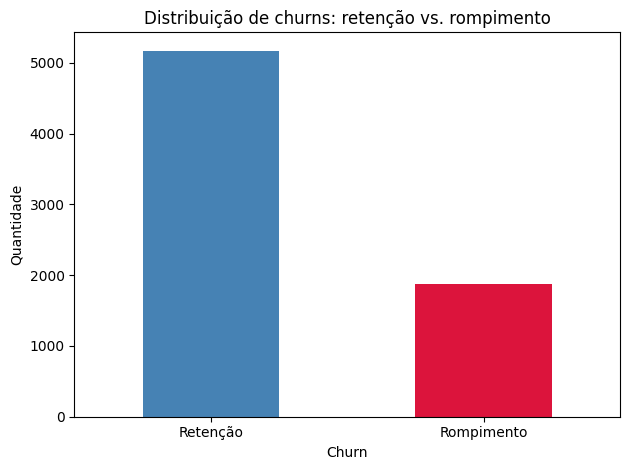

In [61]:
# informações sobre a distribuição dos churns
print(f"Distribuição de churns (rompimento do contrato): \n{df['Churn'].value_counts()}") 
print(f"\nDistribuição de churns em porcentagem: \n{df['Churn'].value_counts(normalize = True) * 100}")

# plot do gráfico de distribuição
df['Churn'].value_counts().plot(
    kind = 'bar',
    color = ['steelblue', 'crimson']
)
plt.title('Distribuição de churns: retenção vs. rompimento')
plt.xticks(
    [0, 1], 
    ['Retenção', 'Rompimento'],
    rotation = 0
)
plt.ylabel('Quantidade')
plt.tight_layout()
plt.savefig('../data/churn_distribution.png')
plt.show

- Há uma desigualdade na distribuição de churns, pois a maioria dos clientes retêm seus contratos.
- Entretanto, é necessário avaliar, também possíveis insights do negócio. Algumas informações que possivelmente influenciam na escolha do cliente: 
    - Tipo de contrato (`Contract`);
    - Tempo de contrato (`tenure`);
    - Serviços contratados (ex: `PhoneService`, `InternetService`, `TechSupport`);
    - Método de Pagamento (`Payment Method`).

## Insights de negócio

### Insights com volume

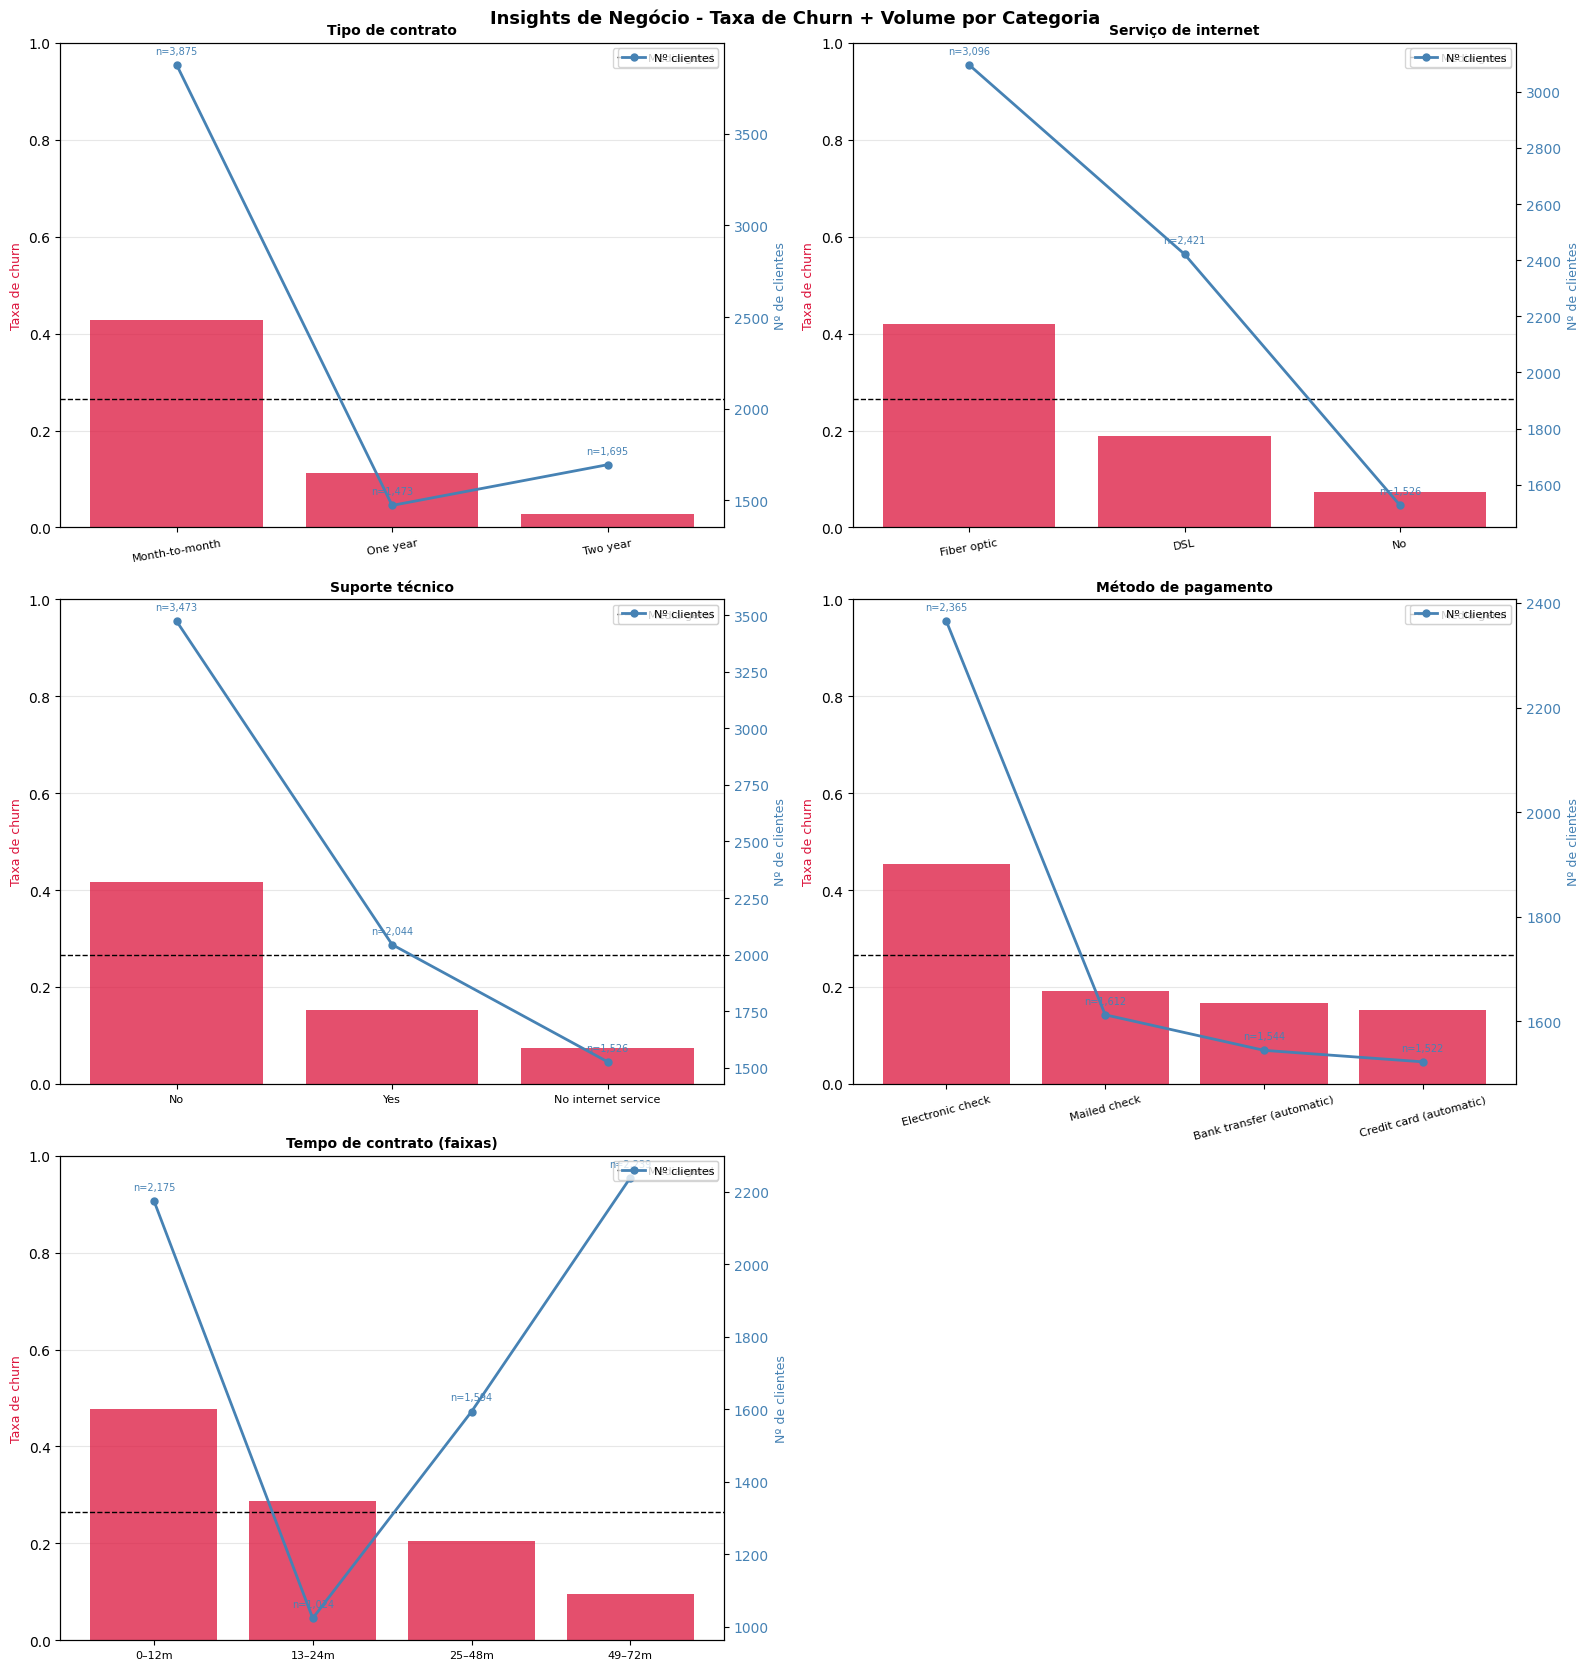

In [62]:
# importação de bibliotecas
import matplotlib.gridspec as gridspec

"""
Plota taxa de churn + volume para variáveis categóricas ou numéricas.
    
Para numéricas, passe bins e labels para criar faixas automaticamente.
Para categóricas, deixe bins e labels como None.
"""
def plot_churn_com_volume(df, coluna, ax, titulo, rotacao = 0, bins = None, labels = None):
    # array com informações de cada insight
    if bins is not None and labels is not None:
        df[coluna] = pd.cut(df[coluna], bins=bins, labels=labels)
    
    resumo = df.groupby(coluna, observed = True).agg(
        total = ('Churn', 'count'),
        churned = ('Churn', lambda x: (x == 'Yes').sum())
    ).reset_index()
    resumo['taxa'] = resumo['churned'] / resumo['total']
    
    if bins is None:
        resumo = resumo.sort_values('taxa', ascending = False)
    
    # plot taxa de churn (barra)
    ax.bar(resumo[coluna], resumo['taxa'], color = 'crimson', alpha = 0.75, zorder = 2)
    ax.axhline(
        df['Churn'].map({
            'Yes': 1,
            'No': 0
        }).mean(),
        color = 'black',
        linestyle = '--',
        linewidth = 1,
        label = 'Média geral'
    )
    ax.set_ylabel('Taxa de churn', color = 'crimson', fontsize = 9)
    ax.set_ylim(0, 1)
    ax.set_title(titulo, fontsize = 10, fontweight = 'bold')
    ax.tick_params(axis = 'x', rotation = rotacao, labelsize = 8)
    ax.legend(fontsize = 8)
    ax.grid(axis = 'y', alpha = 0.3, zorder = 1)

    # plot volume de clientes (linha)
    ax2 = ax.twinx()
    ax2.plot(
        resumo[coluna],
        resumo['total'],
        color = 'steelblue',
        marker = 'o',
        linewidth = 2,
        markersize = 5,
        label = 'Nº clientes'
    )

    for i, row in resumo.iterrows():
        ax2.annotate(
            f"n={row['total']:,}",
            xy=(resumo[coluna].tolist().index(row[coluna]), row['total']),
            xytext=(0, 8), textcoords='offset points',
            ha='center', fontsize=7, color='steelblue'
        )
    
    ax2.set_ylabel('Nº de clientes', color = 'steelblue', fontsize = 9)
    ax2.tick_params(axis = 'y', labelcolor = 'steelblue')
    ax2.legend(loc = 'upper right', fontsize = 8)

# usando uma cópia da base de dados
df_copy = df.copy()

# prepara figura com 4 gráficos
fig, axes = plt.subplots(3, 2, figsize = (16, 17))
fig.suptitle(
    'Insights de Negócio - Taxa de Churn + Volume por Categoria',
    fontsize = 13,
    fontweight = 'bold'
            )

# gráfico tipo de contrato
plot_churn_com_volume(
    df_copy,
    'Contract',
    axes[0, 0],
    'Tipo de contrato',
    rotacao = 10
    )

# gráfico serviço de internet
plot_churn_com_volume(
      df_copy,
      'InternetService',
      axes[0,1],
      'Serviço de internet',
      rotacao = 10
     )

# plot suporte técnico
plot_churn_com_volume(
    df_copy,
    'TechSupport',
    axes[1,0],
    'Suporte técnico',
    rotacao = 0
    )

# plot método de pagamento
plot_churn_com_volume(
    df_copy,
    'PaymentMethod',
    axes[1,1],
    'Método de pagamento',
    rotacao = 15
    )

# plot tempo de contrato
plot_churn_com_volume(
    df_copy, 
    'tenure', 
    axes[2,0],
    titulo = 'Tempo de contrato (faixas)',
    bins = [0, 12, 24, 48, 72],
    labels = ['0–12m', '13–24m', '25–48m', '49–72m']
    )

fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.savefig('../data/churn_insights.png', dpi = 150, bbox_inches = 'tight')
plt.show()

- Tipo de contrato: Clientes com contrato `Month-to-month` têm taxa de churn de ~42%, mais que o dobro da média geral (linha tracejada ~26%). O volume é alto (n = 3.875)então a conclusão é estatisticamente sólida. Contratos anuais e bianuais têm taxas de 11% e 3% respectivamente, com volumes menores mas ainda representativos.
- Serviço de internet: `Fiber optic` se destaca negativamente — taxa de ~41% com o maior volume da categoria (n = 3.096). Isso é preocupante porque não é um grupo pequeno. `DSL` fica bem abaixo da média (~19%) e clientes sem internet têm churn mínimo (~7%). O padrão sugere que o produto de fibra ótica pode ter problemas de qualidade, preço elevado ou expectativas não atendidas.
- Suporte técnico: Clientes sem suporte técnico têm churn de ~41%, quase idêntico ao da fibra ótica — e com volume enorme (n = 3.473). Quem tem suporte cai para ~15%. Clientes sem internet ficam fora do serviço e têm churn baixíssimo. 
- Método de pagamento: `Electronic check` é o único método acima da média (~45%), e com o maior volume (n = 2.365). Os outros três métodos ficam todos abaixo de 20%, praticamente empatados. Isso sugere que não é o método em si que causa churn, mas que electronic check é o método padrão de clientes desengajados — quem nunca atualizou a forma de pagamento tende a ser menos fidelizado.
- Tempo de contrato (faixas de tempo): O gráfico mais rico do conjunto. A faixa 0–12 meses tem churn de ~48% — quase 1 em cada 2 clientes novos cancela. O volume é sólido (n = 2.175). A faixa 13–24m cai bruscamente para ~28%, ainda acima da média. De 25–48m já fica em ~20%, e 49–72m chega a ~8%. A curva da linha azul mostra que a base de clientes está bem distribuída entre as faixas, o que valida todas as taxas. 

### Serviços com volume

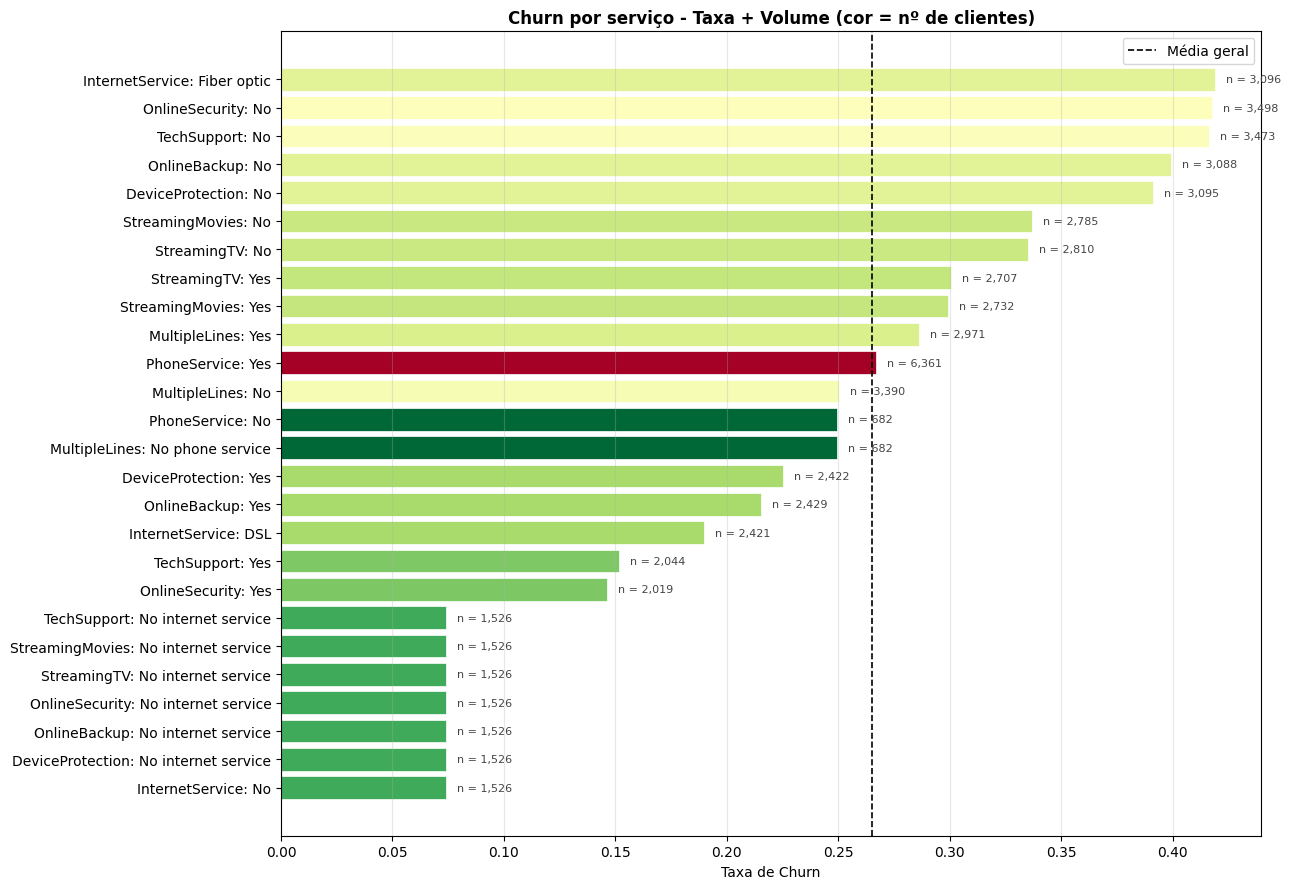

In [63]:
fig, ax = plt.subplots(figsize = (13, 9))

servicos = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

rows = []
for col in servicos:
    for valor, grupo in df.groupby(col):
        taxa = (grupo['Churn'] == 'Yes').mean()
        total = len(grupo)
        rows.append({
            'Categoria': f"{col}: {valor}",
            'Taxa de Churn': taxa,
            'Volume': total
        })

servicos_df = pd.DataFrame(rows).sort_values('Taxa de Churn', ascending = True)

# Volume de clientes (barras)
norm = plt.Normalize(
    servicos_df['Volume'].min(),
    servicos_df['Volume'].max()
    )
cores = plt.cm.RdYlGn_r(norm(servicos_df['Volume']))

bars = ax.barh(
    servicos_df['Categoria'],
    servicos_df['Taxa de Churn'],
    color = cores,
    edgecolor = 'white',
    linewidth = 0.5
)

for bar, vol in zip(bars, servicos_df['Volume']):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'n = {vol:,}',
        va = 'center',
        fontsize = 8,
        color = '#444'
        )

ax.axvline(
    df['Churn'].map({
        'Yes': 1,
        'No': 0
        }).mean(),
    color = 'black',
    linestyle = '--',
    linewidth = 1.2,
    label = 'Média geral'
    )
ax.set_xlabel('Taxa de Churn')
ax.set_title(
    'Churn por serviço - Taxa + Volume (cor = nº de clientes)',
    fontweight = 'bold'
    )
ax.legend()
ax.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.savefig('../data/churn_servicos_detalhes.png', dpi = 150, bbox_inches = 'tight')
plt.show()

- A escala de cor vai do vermelho (mais clientes) ao verde escuro (menos clientes).
- Os 7 últimos itens da lista representam todos o mesmo grupo de n = 1.562 clientes sem internet, onde, inclusive, as taxas de churn são idênticas (~8%).
- Destaque acima da média:
    - `InternetService: Fiber optic`: lidera com ~41% e n = 3.096 (cor amarela clara indicando volume alto). Já apareceu no gráfico 1, aqui fica confirmado.
    - `OnlineSecurity: No` e `TechSupport: No`: vêm logo abaixo com taxas ~42% e volumes gigantes de n = 3.498 e n = 3.473, respectivamente.
- Destaques abaixo da média:
    - `TechSupport: Yes` e `OnlineSecurity: Yes`: têm taxas de ~15% e 14% respectivamente (praticamente metade da média geral) e volumes de n = 2.044 e n = 2.019.
- `PhoneService`: tanto o `Yes` (que possui maior volume em todo gráfico) e o `No` (que possui menor volume no gráfico) estão com taxa de churn próximos da média, indicando que esta variável será pouco importante. 

## Correlação orientada pelos insights

- Agora que encontramos quais são as variáveis mais importantes, também é necessário analisar a correlação para evitar redundâncias durante o treinamento (além de confirmar os achados dos insights).
- Primeiro, será feito uma análise da correlação das variáveis numéricas: `ternure`, `MonthlyCharges`, `TotalCharges` e `Churn`.
- Logo em seguida, será feita a análise da correlação das variáveis categórias mais importantes encontradas nos insights:
    - `Contract`
    - `InternetService`
    - `TechSupport`
    - `OnlineSecurity`
    - `PaymentMethod`
    - `tenure`
    - `MonthlyCharges`
- Por fim, será mostrado um ranking de correlações, buscando encontrar as variáveis mais importantes para o modelo.

### Correlação das variáveis numéricas

- Para a análise da correlação, é necessário a correção do tipo de `TotalCharges` e alguns ajustes no dataframe.

In [64]:
# importando novamento a base pois o pd.cut sobrescreveu algumas colunas
df_copy = df.copy()

# correção do tipo de TotalCharges para análise de correlação
num_df = df_copy[['tenure', 'MonthlyCharges']].copy()
num_df['TotalCharges'] = pd.to_numeric(df_copy['TotalCharges'], errors='coerce')
num_df['Churn'] = (df_copy['Churn'] == 'Yes').astype(int)

print(num_df.dtypes)

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
Churn               int64
dtype: object


<function matplotlib.pyplot.show(close=None, block=None)>

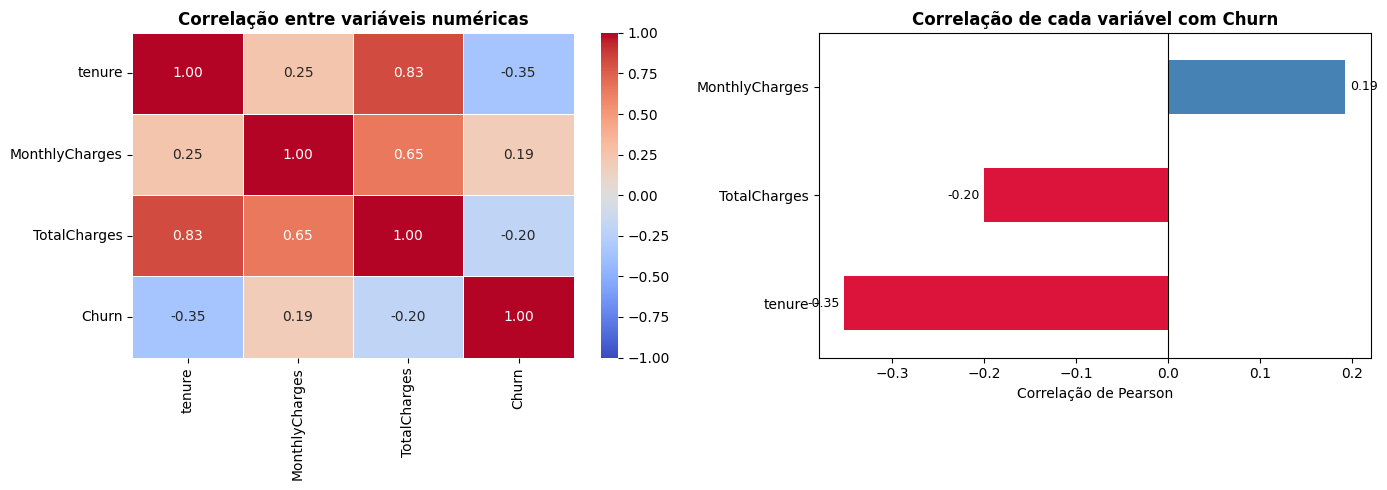

In [65]:
# plot do gráfico
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sns.heatmap(
    num_df.corr(),
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    vmin = -1,
    vmax = 1,
    ax = axes[0],
    linewidths = 0.5
)
axes[0].set_title('Correlação entre variáveis numéricas', fontweight = 'bold')

# correlacao de cada variável com Churns
correlacoes = num_df.corr()['Churn'].drop('Churn').sort_values()
cores = ['crimson' if x < 0 else 'steelblue' for x in correlacoes]
correlacoes.plot(
    kind = 'barh',
    color = cores,
    ax = axes[1]
)
axes[1].set_title('Correlação de cada variável com Churn', fontweight = 'bold')
axes[1].axvline(0, color = 'black', linewidth = 0.8)
axes[1].set_xlabel('Correlação de Pearson')

for i, (val, nome) in enumerate(zip(correlacoes, correlacoes.index)):
    axes[1].text(
        val + (0.005 if val >= 0 else -0.005),
        i, f'{val:.2f}',
        va = 'center',
        ha = 'left' if val >= 0 else 'right',
        fontsize = 9
    )

plt.tight_layout()
plt.savefig('../data/correlation_numericas.png', dpi = 150, bbox_inches = 'tight')
plt.show

- Há uma correlação alta (0.83) entre `ternure` e `TotalCharges`, afinal, há uma relação óbvia entre ambos: quanto mais meses o cliente passar, maior será o montante final.
- Para evitar redundências e confusão do modelo, será necessário remover uma das duas variáveis. Nesse caso, como `TotalCharges` é um produto de `ternure x MonthlyCharges`, ela que será a coluna removida no pré-processamento.

### Correlação absoluta das variáveis categóricas com Churn

- É necessário converter as categorias em dummies temporariamente para medir a correlação. Isso permite ranquear as variáveis por revelância antes do treinamento.
- Também é importante pontuar que a correlação absoluta implica em analisar a "força" da relação e não a "direção", como veio sendo feito ao longo da EDA. Ou seja, agora analisa-se o quanto cada variável aumenta ou diminui diretamente o Churn.

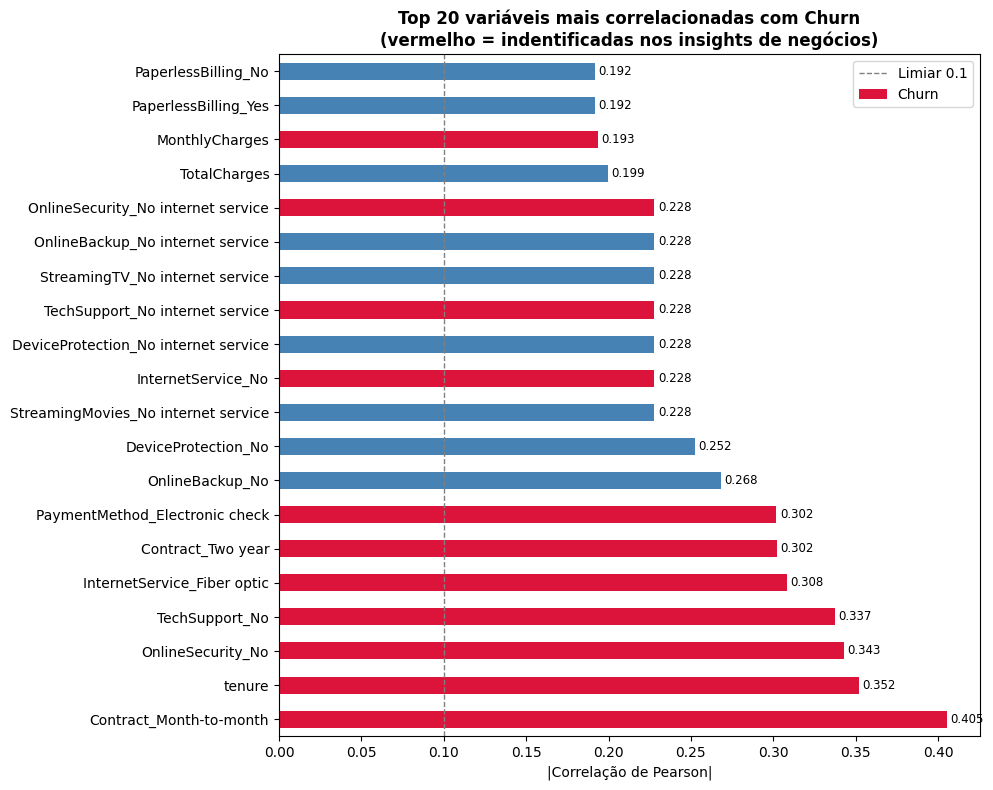

In [73]:
# transformação de categorias em dummies
df_copy = df.copy()

df_copy['Churn'] = (df_copy['Churn'] == 'Yes').astype(int)
df_copy['TotalCharges'] = pd.to_numeric(df_copy['TotalCharges'], errors = 'coerce')
df_copy = df_copy.drop('customerID', axis = 1)

vars_destaque = [
    'Contract', 'InternetService', 'TechSupport',
    'OnlineSecurity', 'PaymentMethod', 'tenure', 'MonthlyCharges'
]

cat_cols = df_copy.select_dtypes(include = 'object').columns.tolist()
df_encoded = pd.get_dummies(df_copy, columns = cat_cols, drop_first = False)

# correlação entre categorias e Churn
corr_churn = (
    df_encoded.corr()['Churn']
    .drop('Churn')
    .abs()
    .sort_values(ascending = False)
    .head(20)
)

fig, ax = plt.subplots(figsize = (10, 8))

cores = []
for col in corr_churn.index:
    if any(v in col for v in vars_destaque):
        cores.append('crimson')
    else:
        cores.append('steelblue')

corr_churn.plot(
    kind = 'barh',
    ax = ax,
    color = cores
    )
ax.set_title(
    'Top 20 variáveis mais correlacionadas com Churn\n'
    '(vermelho = indentificadas nos insights de negócios)',
    fontweight = 'bold'
    )
ax.set_xlabel('|Correlação de Pearson|')
ax.axvline(
    0.1,
    color = 'gray',
    linestyle = '--',
    linewidth = 1,
    label = 'Limiar 0.1'
    )
ax.legend()

for i, val in enumerate(corr_churn):
    ax.text(
        val + 0.002,
        i,
        f'{val:.3f}',
        va = 'center',
        fontsize = 8.5
        )

plt.tight_layout()
plt.savefig('../data/correlation_categorias.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [75]:
# ranking dos insights na correlação
print("=" * 55)
print("  Ranking de correlação — variáveis dos insights")
print("=" * 55)

for var in vars_destaque:
    matches = [(col, val) for col, val in corr_churn.items() if var in col]
    if matches:
        for col, val in matches:
            print(f"  {col:<40} {val:.3f}")
    else:
        print(f"  {var:<40} (não entrou no top 20)")

  Ranking de correlação — variáveis dos insights
  Contract_Month-to-month                  0.405
  Contract_Two year                        0.302
  InternetService_Fiber optic              0.308
  InternetService_No                       0.228
  TechSupport_No                           0.337
  TechSupport_No internet service          0.228
  OnlineSecurity_No                        0.343
  OnlineSecurity_No internet service       0.228
  PaymentMethod_Electronic check           0.302
  tenure                                   0.352
  MonthlyCharges                           0.193


- Dentre as vinte variáveis mais correlacionadas com Churn (as que provavelmente serão consideradas pelo modelo), existem onze variáveis já analisadas nos insights de negócio.
- Os principais insights de negócio identificados na correlação absoluta foram:
    - `Contract: Month-to-month`: 0.405 (contratos mensais não garantem fidelidade do cliente).
    - `tenure`: 0.352 (quanto menos tempo como cliente da empresa, maior chance de churn).
    - `OnlineSecurity: No` e `TechSupport: No`: 0.342 e 0.337, respectivamente (ausência de serviços extras causam churn. Clientes com pacotes básicos são voláteis).
    - `InternetService: Fiber optic`: 0.308 (a fibra ótica, provavelmente, quebra as expectativas dos clientes. Não é possível determinar com exatidão o motivo).
- De forma geral:
    - Variáveis com |correlação| > 0.15 possuem influência relevante.
    - Variáveis com |correlação| < 0.05 provavelmente serão descartadas pelo modelo ou terão baixa importância.